# Temporal Convolutional Network for AAPL Trend Prediction

## Objective

Train a Temporal Convolutional Network (TCN) to classify the
short-term trend of AAPL as Rise or Fall.

Each sample contains 22 historical trading days and 9 input features.

The model is intentionally kept compact because the available
training dataset is relatively small.

In [49]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Device:", device)

PyTorch: 2.13.0
Device: mps


In [50]:
X_train = np.load("../data/processed/X_train_scaled.npy")
X_val = np.load("../data/processed/X_val_scaled.npy")
X_test = np.load("../data/processed/X_test_scaled.npy")

y_train = np.load("../data/processed/y_train.npy")
y_val = np.load("../data/processed/y_val.npy")
y_test = np.load("../data/processed/y_test.npy")

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (120, 22, 9) (120,)
Validation: (40, 22, 9) (40,)
Test: (40, 22, 9) (40,)


In [51]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
).permute(0, 2, 1)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
).permute(0, 2, 1)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
).permute(0, 2, 1)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

In [52]:
print(X_train_tensor.shape)

torch.Size([120, 9, 22])


In [53]:
BATCH_SIZE = 16

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [54]:
class TCNBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        dilation,
        dropout=0.2
    ):
        super().__init__()

        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation
        )

        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation
        )

        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.residual = (
            nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=1
            )
            if in_channels != out_channels
            else nn.Identity()
        )

    def forward(self, x):
        residual = self.residual(x)

        x = self.conv1(x)

        # Remove extra right-side padding to preserve sequence length
        x = x[:, :, :residual.size(2)]

        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.conv2(x)

        x = x[:, :, :residual.size(2)]

        x = self.relu2(x)
        x = self.dropout2(x)

        return x + residual

In [55]:
class AAPLTCN(nn.Module):
    def __init__(self, num_features=9, num_classes=2):
        super().__init__()

        self.tcn = nn.Sequential(
            TCNBlock(
                in_channels=num_features,
                out_channels=32,
                kernel_size=3,
                dilation=1
            ),

            TCNBlock(
                in_channels=32,
                out_channels=32,
                kernel_size=3,
                dilation=2
            )
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.tcn(x)
        x = self.classifier(x)

        return x

In [56]:
model = AAPLTCN(
    num_features=9,
    num_classes=2
).to(device)

print(model)

AAPLTCN(
  (tcn): Sequential(
    (0): TCNBlock(
      (conv1): Conv1d(9, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (relu1): ReLU()
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (relu2): ReLU()
      (dropout2): Dropout(p=0.2, inplace=False)
      (residual): Conv1d(9, 32, kernel_size=(1,), stride=(1,))
    )
    (1): TCNBlock(
      (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (relu1): ReLU()
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (relu2): ReLU()
      (dropout2): Dropout(p=0.2, inplace=False)
      (residual): Identity()
    )
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool1d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [57]:
total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nTrainable parameters:", total_params)


Trainable parameters: 10594


In [58]:
sample_batch = X_train_tensor[:4].to(device)

with torch.no_grad():
    output = model(sample_batch)

print("Input:", sample_batch.shape)
print("Output:", output.shape)

Input: torch.Size([4, 9, 22])
Output: torch.Size([4, 2])


In [59]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [60]:
EPOCHS = 100
PATIENCE = 15

In [61]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
best_state = None
patience_counter = 0

In [62]:
for epoch in range(EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = model(batch_X)

        loss = criterion(logits, batch_y)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

        predictions = torch.argmax(
            logits,
            dim=1
        )

        correct += (
            predictions == batch_y
        ).sum().item()

        total += batch_y.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for batch_X, batch_y in val_loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_X)

            loss = criterion(
                logits,
                batch_y
            )

            val_running_loss += (
                loss.item()
                * batch_X.size(0)
            )

            predictions = torch.argmax(
                logits,
                dim=1
            )

            val_correct += (
                predictions == batch_y
            ).sum().item()

            val_total += batch_y.size(0)

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # -------------------------
    # Early stopping
    # -------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_state = {
            key: value.cpu().clone()
            for key, value
            in model.state_dict().items()
        }

        patience_counter = 0

    else:

        patience_counter += 1

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch + 1:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.3f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.3f}"
        )

    if patience_counter >= PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch + 1}"
        )

        break

Epoch 010 | Train Loss: 0.5582 | Train Acc: 0.717 | Val Loss: 1.9567 | Val Acc: 0.350

Early stopping at epoch 16


In [63]:
model.load_state_dict(best_state)

model = model.to(device)

print("Best validation loss:", best_val_loss)

Best validation loss: 1.1902376890182496


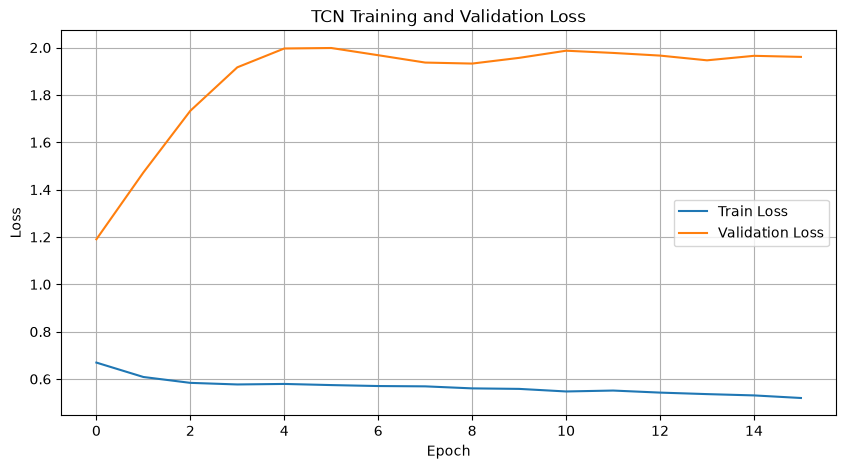

In [64]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TCN Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

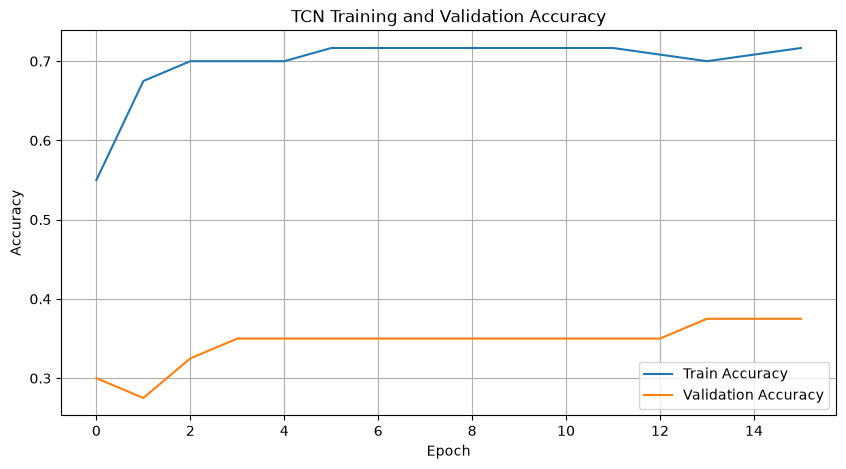

In [65]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_accuracies,
    label="Train Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("TCN Training and Validation Accuracy")

plt.legend()
plt.grid(True)
plt.show()

In [66]:
import os

os.makedirs("../models", exist_ok=True)

In [67]:
model_path = "../models/aapl_tcn.pt"

torch.save(
    model.state_dict(),
    model_path
)

print("Saved:", model_path)

Saved: ../models/aapl_tcn.pt
